# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [147]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

In [148]:
df = pd.read_csv("train.csv")
df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [149]:
# Show basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [150]:
# Remove rows with missing values
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [151]:
# Check target values and their quantities
df['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

text lenghts value counts
text
41     308
48     301
46     301
42     298
45     295
      ... 
4        8
3        5
139      4
141      2
140      1
Name: count, Length: 139, dtype: int64


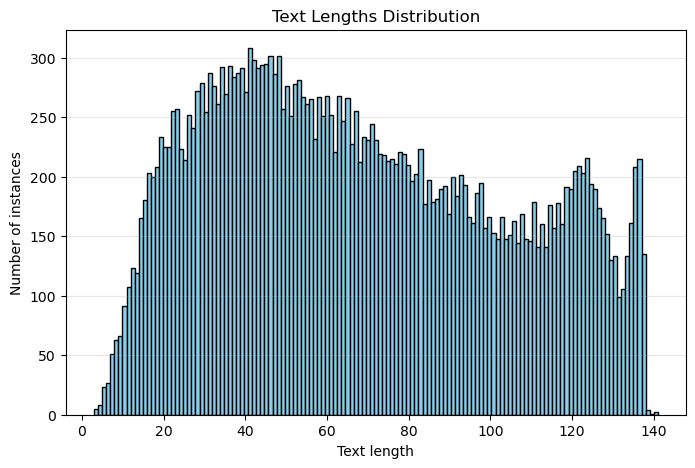

In [152]:
# Get text lengths
text_lengths = df['text'].str.len()

# Show text lenghts value counts
text_lengths_counts = text_lengths.value_counts()
print("text lenghts value counts")
print(text_lengths_counts)

# Show distribution on a histogram
plt.figure(figsize=(8, 5))
plt.hist(
    text_lengths,
    bins=len(text_lengths_counts),
    color='skyblue',
    edgecolor='black'
)
plt.title('Text Lengths Distribution')
plt.xlabel('Text length')
plt.ylabel('Number of instances')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Observations**
- Text lengths have right-side (positively) skewed distribution.
- The most frequent post length is 41.
- There are also local maximums at 124 and 137.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [153]:
# Define stopwords and Stemmer
english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer(language='english')


# Function to tokenize text and stem tokens
def tokenize(text):
    tokens = word_tokenize(text)
    return [stemmer.stem(token) for token in tokens if token.lower() not in english_stopwords]


# Create vectors
vectorizer = CountVectorizer(
    tokenizer=tokenize,
    token_pattern=None
)
vectors = vectorizer.fit_transform(df['text'])
vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 243282 stored elements and shape (27480, 23154)>

In [154]:
# Show first 100 vacabulary tokens
print(list(vectorizer.vocabulary_.keys())[:100])

['`', 'respond', ',', 'go', 'sooo', 'sad', 'miss', 'san', 'diego', '!', 'boss', 'bulli', '...', 'interview', 'leav', 'alon', 'son', '*', 'put', 'releas', 'alreadi', 'bought', 'http', ':', '//www.dothebouncy.com/smf', '-', 'shameless', 'plug', 'best', 'ranger', 'forum', 'earth', '2am', 'feed', 'babi', 'fun', 'smile', 'coo', 'soooo', 'high', 'journey', '?', 'wow', 'u', 'becam', 'cooler', '.', 'hehe', '(', 'possibl', ')', 'much', 'love', 'hope', 'reckon', 'chanc', 'minim', '=p', 'never', 'gon', 'na', 'get', 'cake', 'stuff', 'realli', 'like', 'song', 'stori', 'taylor', 'swift', 'sharpi', 'run', 'danger', 'low', 'ink', 'want', 'music', 'tonight', 'lost', 'voic', 'test', 'lg', 'env2', 'uh', 'oh', 'sunburn', 'ok', 'tri', 'plot', 'altern', 'speak', 'sigh', 'sick', 'past', 'day', 'thus', 'hair', 'look', 'wierd', 'didnt']


Based on results, let's make vocabulary smaller.

In [155]:
# Add some symbols to stopwords
custom_stopwords = ['`', ':', '-', '.', '(', ')'] + english_stopwords
print(custom_stopwords)

['`', ':', '-', '.', '(', ')', 'a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 

In [156]:
# Redefine tokenize function with new stopwords set
def tokenize(text):
    tokens = word_tokenize(text)
    return [stemmer.stem(token) for token in tokens if token.lower() not in custom_stopwords]

In [157]:
# Create vectors with limiting min usages of tokens (low impact / typos)
# and max usages (potential stopwords)
vectorizer = CountVectorizer(
    tokenizer=tokenize,
    token_pattern=None,
    min_df=3,
    max_df=0.9
)
vectors = vectorizer.fit_transform(df['text'])
vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 200535 stored elements and shape (27480, 5695)>

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [158]:
# Split inputs (vectorized text) and targets (sentiment)
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    vectors,
    df['sentiment'],
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=27
)
X_train_bow.shape, X_test_bow.shape, y_train.shape, y_test.shape

((21984, 5695), (5496, 5695), (21984,), (5496,))

In [159]:
# Train and make predictions with LogisticRegression
log_reg = LogisticRegression(random_state=27, max_iter=500)
log_reg.fit(X_train_bow, y_train)
preds_train = log_reg.predict(X_train_bow)
preds_test = log_reg.predict(X_test_bow)

In [160]:
# Show classification scores for train and test
print("TRAIN")
print(classification_report(y_train, preds_train))
print("TEST")
print(classification_report(y_test, preds_test))

TRAIN
              precision    recall  f1-score   support

    negative       0.86      0.78      0.82      6225
     neutral       0.79      0.86      0.82      8894
    positive       0.86      0.83      0.85      6865

    accuracy                           0.83     21984
   macro avg       0.84      0.83      0.83     21984
weighted avg       0.83      0.83      0.83     21984

TEST
              precision    recall  f1-score   support

    negative       0.72      0.62      0.67      1556
     neutral       0.64      0.73      0.68      2223
    positive       0.77      0.72      0.74      1717

    accuracy                           0.70      5496
   macro avg       0.71      0.69      0.70      5496
weighted avg       0.70      0.70      0.70      5496



In [161]:
# Train and make predictions with KNeighborsClassifier
kNN = KNeighborsClassifier()
kNN.fit(X_train_bow, y_train)
preds_train = kNN.predict(X_train_bow)
preds_test = kNN.predict(X_test_bow)

In [162]:
# Show classification scores for train and test
print("TRAIN")
print(classification_report(y_train, preds_train))
print("TEST")
print(classification_report(y_test, preds_test))

TRAIN
              precision    recall  f1-score   support

    negative       0.72      0.43      0.54      6225
     neutral       0.55      0.90      0.68      8894
    positive       0.86      0.49      0.62      6865

    accuracy                           0.64     21984
   macro avg       0.71      0.60      0.61     21984
weighted avg       0.70      0.64      0.62     21984

TEST
              precision    recall  f1-score   support

    negative       0.62      0.30      0.40      1556
     neutral       0.48      0.84      0.61      2223
    positive       0.74      0.36      0.48      1717

    accuracy                           0.54      5496
   macro avg       0.61      0.50      0.50      5496
weighted avg       0.60      0.54      0.51      5496



In [163]:
# Train and make predictions with LGBMClassifier
lgbm = LGBMClassifier(
    random_state=27,
    verbose=-1
)
lgbm.fit(X_train_bow.astype('float32'), y_train)
preds_train = lgbm.predict(X_train_bow.astype('float32'))
preds_test = lgbm.predict(X_test_bow.astype('float32'))

In [164]:
# Show classification scores for train and test
print("TRAIN")
print(classification_report(y_train, preds_train))
print("TEST")
print(classification_report(y_test, preds_test))

TRAIN
              precision    recall  f1-score   support

    negative       0.80      0.64      0.71      6225
     neutral       0.69      0.81      0.75      8894
    positive       0.80      0.77      0.79      6865

    accuracy                           0.75     21984
   macro avg       0.76      0.74      0.75     21984
weighted avg       0.76      0.75      0.75     21984

TEST
              precision    recall  f1-score   support

    negative       0.76      0.61      0.68      1556
     neutral       0.66      0.76      0.71      2223
    positive       0.77      0.74      0.76      1717

    accuracy                           0.71      5496
   macro avg       0.73      0.71      0.71      5496
weighted avg       0.72      0.71      0.71      5496



**Summary**
- The best results is shown by LGBMClassifier model, because its F1 scores for Train and Test are close and pretty good.
- I would evaluate selected model (LGBMClassifier) quality as acceptable, though it has potential to be improved (hyperparameters selection, improving vocabulary)

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [165]:
# Show 20 most important and 20 least important tokens of a model
feature_imporances = pd.Series(
    lgbm.feature_importances_,
    index=vectorizer.get_feature_names_out(),
    name='importance score'
).sort_values(ascending=False)

print('Most important:')
print(feature_imporances[:20])
print('\nLeast important:')
print(feature_imporances[-20:])

Most important:
!         153
love      115
miss      100
good       98
thank      96
,          83
awesom     82
hope       79
sorri      79
sad        78
great      73
bad        73
?          69
happi      68
suck       68
nice       65
hate       63
fun        61
glad       59
*          59
Name: importance score, dtype: int32

Least important:
flop            0
florida         0
focus           0
fone            0
followin        0
followfriday    0
folk            0
fold            0
foggi           0
fog             0
foam            0
flow            0
fo              0
fml             0
flyer           0
flush           0
fluid           0
fluffi          0
flu             0
ï¿½ï¿½          0
Name: importance score, dtype: int32


**Summary**
- It makes sense that most important tokens express some emotions or attitude to something, like `love`, `miss`, `good`, `bad`, `hate`.
- Punctuation symbols between most important features might also express some emotions, but it also can be a noise.
- 20 least important tokens have 0 importance score - it makes sense, model just didn't consider a lot of the tokens in its calculations.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [166]:
# Create TfidfVectorizer with the same params as CountVectorizer
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=tokenize,
    token_pattern=None,
    min_df=3,
    max_df=0.9
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 200535 stored elements and shape (27480, 5695)>

In [167]:
# Split inputs (tfidf matrix) and targets (sentiment)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_matrix,
    df['sentiment'],
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=27
)
X_train_tfidf.shape, X_test_tfidf.shape, y_train.shape, y_test.shape

((21984, 5695), (5496, 5695), (21984,), (5496,))

In [168]:
# Check whether splitting for BOW and TF-IDF is the same
print(X_test_bow.indices)
print(X_test_tfidf.indices)

[   8 3100 5420 ...  654 5285 5554]
[   8 3100 5420 ...  654 5285 5554]


In [169]:
# Train and make predictions with LGBMClassifier
lgbm = LGBMClassifier(
    random_state=27,
    verbose=-1
)
lgbm.fit(X_train_tfidf.astype('float32'), y_train)
preds_train = lgbm.predict(X_train_tfidf.astype('float32'))
preds_test = lgbm.predict(X_test_tfidf.astype('float32'))

In [170]:
# Show classification scores for train and test
print("TRAIN")
print(classification_report(y_train, preds_train))
print("TEST")
print(classification_report(y_test, preds_test))

TRAIN
              precision    recall  f1-score   support

    negative       0.81      0.65      0.72      6225
     neutral       0.70      0.83      0.76      8894
    positive       0.82      0.78      0.80      6865

    accuracy                           0.76     21984
   macro avg       0.78      0.75      0.76     21984
weighted avg       0.77      0.76      0.76     21984

TEST
              precision    recall  f1-score   support

    negative       0.76      0.61      0.67      1556
     neutral       0.65      0.77      0.70      2223
    positive       0.78      0.73      0.75      1717

    accuracy                           0.71      5496
   macro avg       0.73      0.70      0.71      5496
weighted avg       0.72      0.71      0.71      5496



In [171]:
# Show 20 most important and 20 least important tokens of a model
feature_imporances = pd.Series(
    lgbm.feature_importances_,
    index=tfidf_vectorizer.get_feature_names_out(),
    name='importance score'
).sort_values(ascending=False)

print('Most important:')
print(feature_imporances[:20])
print('\nLeast important:')
print(feature_imporances[-20:])

Most important:
love      121
thank     109
!         103
miss      102
good      100
sorri      98
happi      93
hope       92
great      91
awesom     83
sad        80
nice       76
hate       72
suck       71
bad        71
?          69
feel       63
enjoy      63
like       62
glad       61
Name: importance score, dtype: int32

Least important:
flat       0
flavor     0
flood      0
fluid      0
fluffi     0
flu        0
flower     0
flow       0
florida    0
flop       0
float      0
flew       0
flo        0
flirt      0
flippin    0
flip       0
flight     0
flickr     0
flick      0
ï¿½ï¿½     0
Name: importance score, dtype: int32


Most important:
!         153
love      115
miss      100
good       98
thank      96
,          83
awesom     82
hope       79
sorri      79
sad        78
great      73
bad        73
?          69
happi      68
suck       68
nice       65
hate       63
fun        61
glad       59
*          59
Name: importance score, dtype: int32

Least important:
flop            0
florida         0
focus           0
fone            0
followin        0
followfriday    0
folk            0
fold            0
foggi           0
fog             0
foam            0
flow            0
fo              0
fml             0
flyer           0
flush           0
fluid           0
fluffi          0
flu             0
ï¿½ï¿½          0

**Summary**
- Results for TF-IDF are pretty much the same as for BOW using LightGBM Classifier.
- TF-IDF has slightly better F1 scores on Train, and slightly worse F1 scores on Test.
- Most and least important tokens are very similar for TF-IDF and BOW.
- I would choose BOW in this particular case, because its Test scores are a bit closer to Train scores.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [172]:
# Make a prediction on the whole data set
df['prediction'] = lgbm.predict(tfidf_matrix)

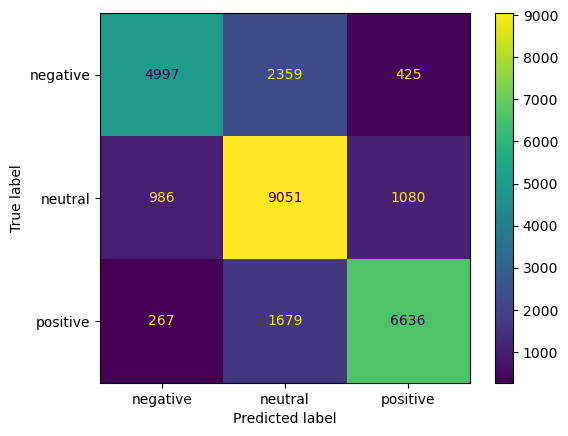

In [173]:
# Show confusion matrix
cm = confusion_matrix(df['sentiment'], df['prediction'], labels=lgbm.classes_)
cm_disp = ConfusionMatrixDisplay(cm, display_labels=lgbm.classes_)
cm_disp.plot()
plt.show()

In [174]:
# Calculate probabilities for all the data
tfidf_proba = lgbm.predict_proba(tfidf_matrix)
tfidf_proba_df = pd.DataFrame(tfidf_proba, columns=lgbm.classes_)
tfidf_proba_df

,negative,neutral,positive
0,0.184538,0.687086,0.128376
1,0.861179,0.129704,0.009117
2,0.269172,0.609102,0.121726
3,0.329543,0.425753,0.244704
4,0.614303,0.253276,0.132421
...,...,...,...
27475,0.620702,0.228501,0.150796
27476,0.236298,0.630808,0.132894
27477,0.031350,0.210040,0.758610
27478,0.352994,0.166322,0.480685


In [175]:
# Display some wrongly predicted instance texts
for i in lgbm.classes_:
    for j in lgbm.classes_:
        if i != j:
            with pd.option_context('display.max_colwidth', None):
                df_to_display = df[(df['sentiment'] == i) & (df['prediction'] == j)]
                print(f"ACTUAL: {i}, PREDICTED: {j} ({df_to_display.shape[0]} instances)" )
                display(df_to_display.text.head())
                print('\n')

ACTUAL: negative, PREDICTED: neutral (2359 instances)


2                                                          my boss is bullying me...
3                                                     what interview! leave me alone
12                                      My Sharpie is running DANGERously low on ink
16                              S`ok, trying to plot alternatives as we speak *sigh*
29    Went to sleep and there is a power cut in Noida  Power back up not working too
Name: text, dtype: object



ACTUAL: negative, PREDICTED: positive (425 instances)


76                 WOW, i AM REALLY MiSSiN THE FAM(iLY) TODAY. BADDD.
103    i realy wanted to go out cause its so nice but everybodys busy
139       missed all the awesome weather, because she was in a movie!
178                 really hopes her car`s illness is not terminal...
369                      l`m on 3 days too matt. No fun this weekend.
Name: text, dtype: object



ACTUAL: neutral, PREDICTED: negative (986 instances)


...

5                                 http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth
10                  as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff
34                       Ahhh, I slept through the game.  I`m gonna try my best to watch tomorrow though. I hope we play Army.
40                  Car not happy, big big dent in boot! Hoping theyre not going to write it off, crossing fingers and waiting
74     she is good! so gor-juz yea i kno i asked her yesterday when we were at tha hospital if she talked to u and she said no
Name: text, dtype: object



ACTUAL: positive, PREDICTED: negative (267 instances)


213                                                                       We never miss ICarly - my son has a huge crush on Miranda
217                                                                                                      Feeling smooth like chrome
252    almost died. Laptop screen was set to 100% brightness after I reinstalled Windows Vista. Got a headache now  #insanedefaults
267                                                    can`t school just be done already? it hurts too much... seeing him every day
407                                               yep infact she is popular, miss india 99, talented film actress .... and lot more
Name: text, dtype: object



ACTUAL: positive, PREDICTED: neutral (1679 instances)


9                      Journey!? Wow... u just became cooler.  hehe... (is that possible!?)
30     I`m going home now. Have you seen my new twitter design? Quite....heavenly isn`****?
68                                                                                 Chilliin
108                  have a safe trip joshy poo.......you`ll knock them dead at your speech
117                                                                   hahaa your awesomee !
Name: text, dtype: object

**Observations**
- ACTUAL: negative, PREDICTED: neutral (2359 instances) - negative context is missed in separate words like `bullying`, `sigh` and phrases like `leave me alone`, `power cut`.
- ACTUAL: negative PREDICTED: positive (425 instances) - also missed negative context in words and phrases.
- ACTUAL: neutral, PREDICTED: negative (986 instances) - some instances might be wrongly marked as neutral, while having negative tone.
- ACTUAL: neutral, PREDICTED: positive (1080 instances) - some instances might be predicted positive based on separate word, while other words in sentence change its meaning, like `hopeful` in `as much as i love to be hopeful` or `happy` in `not happy`.
- ACTUAL: positive, PREDICTED: negative (267 instances) - some instances might be wrongly labeled as positive and other might be wrongly predicted by separate words, missing whole context, like `miss` in `We never miss`.
- ACTUAL: positive, PREDICTED: neutral (1679 instances) - missed positive context in some words and phrases, in some of them because of typos, like in `awesomee`.

**Suggestions for improvement**
- Include some context awareness, at least some words can be merged with others into one token, for example word `not`.
- Fix wrongly labeled instances in the data.
- Give some tokens more weight to define positive or negative context more strongly.
- Fix typos.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model